In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

from xgboost import XGBClassifier
from xgboost import plot_importance

import joblib

In [4]:
df = pd.read_csv('alzheimers_disease_data.csv')

df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [10]:
df.shape

(2149, 35)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [12]:
df['Diagnosis'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
2144    1
2145    1
2146    1
2147    1
2148    0
Name: Diagnosis, Length: 2149, dtype: int64>

In [14]:
df = df.drop(columns=['PatientID', 'DoctorInCharge'])

df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='object')

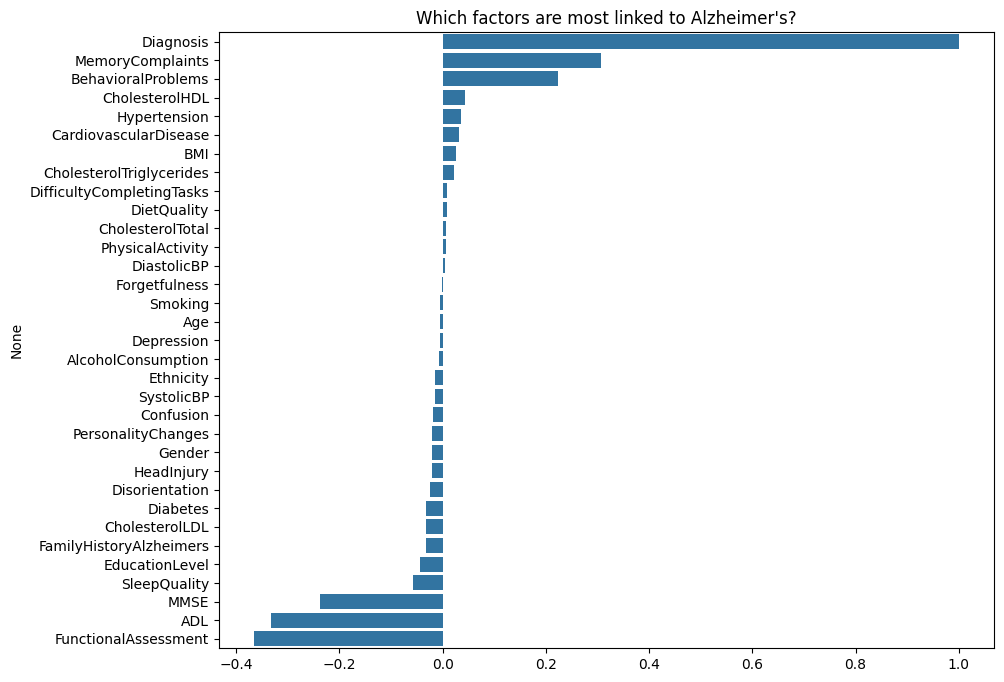

In [16]:
correlations = df.corr()['Diagnosis'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index)
plt.title('Which factors are most linked to Alzheimer\'s?')
plt.show()


In [17]:
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"The model is {accuracy * 100:.2f}% accurate!")

The model is 92.56% accurate!


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       277
           1       0.96      0.82      0.89       153

    accuracy                           0.93       430
   macro avg       0.94      0.90      0.92       430
weighted avg       0.93      0.93      0.92       430


Confusion Matrix Array:
[[272   5]
 [ 27 126]]


<Figure size 800x600 with 0 Axes>

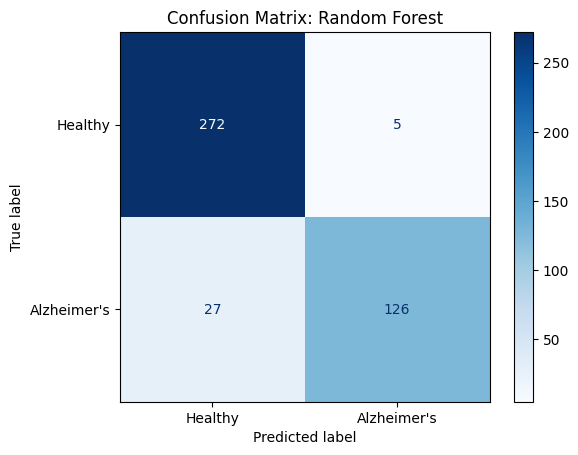

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Alzheimer\'s'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Random Forest')
plt.savefig('Confusion_matrix_rf.png')

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)
print("\nConfusion Matrix Array:")
print(cm)

In [22]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state = 42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")

print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 95.12%
XGBoost Confusion Matrix:
[[270   7]
 [ 14 139]]


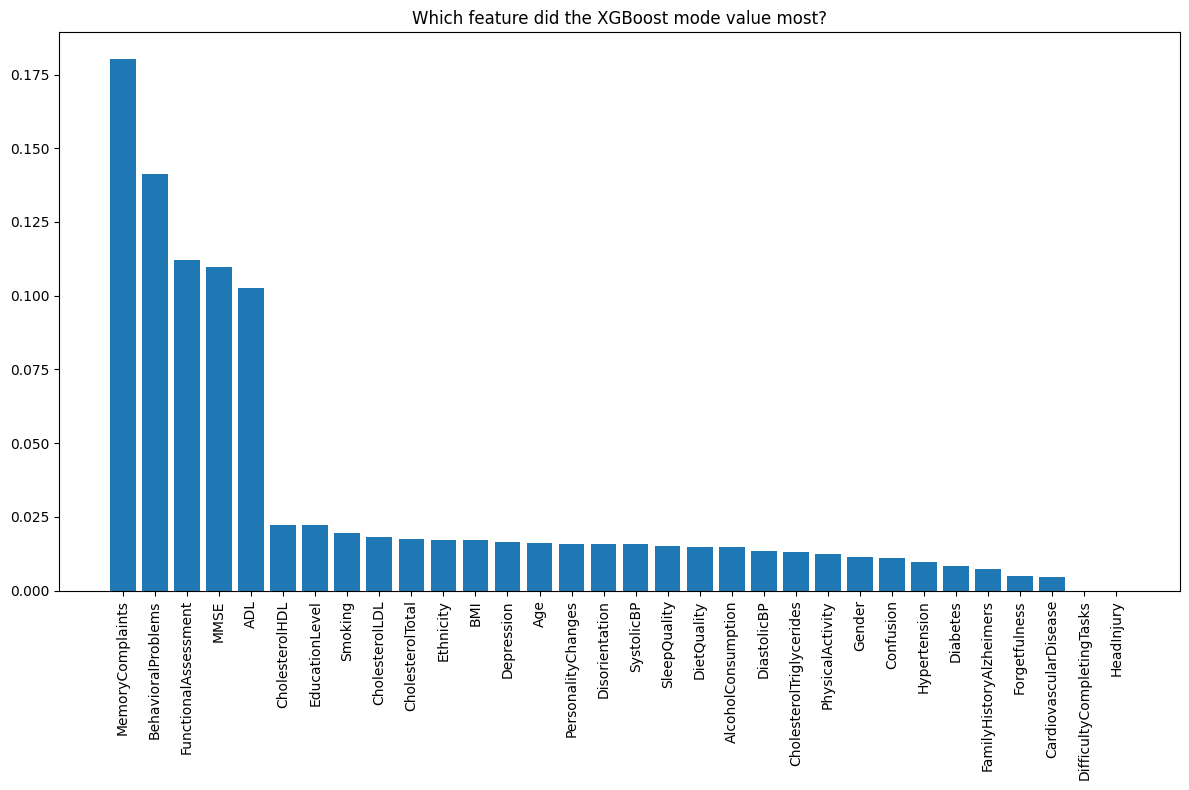

The top 3 most important features were:
1. MemoryComplaints
2. BehavioralProblems
3. FunctionalAssessment


In [23]:
importance = xgb_model.feature_importances_
feature_names = X.columns

indices = np.argsort(importance)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Which feature did the XGBoost mode value most?")
plt.bar(range(X.shape[1]), importance[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i]for i in indices], rotation=90)
plt.tight_layout()
plt.show()

print("The top 3 most important features were:")
for i in range(3):
    print(f"{i+1}. {feature_names[indices[i]]}")

In [24]:
def predict_alzheimers(patient_data):
    patient_df = pd.DataFrame([patient_data], columns=X.columns)

    prediction = xgb_model.predict(patient_df)[0]
    probability = xgb_model.predict_proba(patient_df)[0][1]

    status = "Alzheimer's Detected" if prediction == 1 else "Healthy/Low Risk"
    print(f"Prediction: {status}")
    print(f"Confidence: {probability * 100:.2f}%")


sample_patient = X_test.iloc[0].copy()
sample_patient['MemoryComplaints'] = 1 
sample_patient['FunctionAssessment'] = 1.0
sample_patient['MMSE'] = 5.0

predict_alzheimers(sample_patient)

Prediction: Healthy/Low Risk
Confidence: 0.94%


In [25]:
y_probs = xgb_model.predict_proba(X_test)[:,1]

y_pred_sensitive = (y_probs >= 0.3).astype(int)

cm_v01 = confusion_matrix(y_test, y_pred_sensitive)

print("New Confusion Matrix (Threshold 0.3):")
print(cm_v01)

missed_cases = cm_v01[1, 0]
print(f"\nPatients missed with new Threshold: {missed_cases}")

New Confusion Matrix (Threshold 0.3):
[[270   7]
 [ 13 140]]

Patients missed with new Threshold: 13


In [27]:
joblib.dump(xgb_model, 'alzheimers_model.pkl')

joblib.dump(X.columns, 'model_features.pkl')

print("Model saved sucessfully!")

Model saved sucessfully!


In [38]:
xgb_medical = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=2,
    learning_rate=0.1,
    random_state=42
)

xgb_medical.fit(X_train, y_train)

y_pred_medical = xgb_medical.predict(X_test)
cm_medical = confusion_matrix(y_test, y_pred_medical)

print("XGBoost with Medical Weighting:")
print(cm_medical)
print(f"missed_cases:{cm_medical[1,0]}")

XGBoost with Medical Weighting:
[[270   7]
 [ 15 138]]
missed_cases:15
